In [83]:
import pandas as pd
import numpy as np

In [84]:
df=pd.read_csv("https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv")

In [85]:
df

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1206,3551,4638,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,1296,3211,8016,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,856,3260,8809,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,1296,3211,8946,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


1.Explore the Dataset:

Analyze the mobile price dataset to understand its structure, feature distributions, and relationships before model building.

Perform the following:

Inspect dataset shape, columns, data types, and missing values

Generate statistical summaries for numerical features

Create a correlation heatmap focusing on Price

Identify the top 4 features most correlated with Price

Plot scatter plots for these features against Price and analyze the relationships


In [86]:
df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='str')

In [87]:
df.rename(columns=str.title,inplace=True)

In [88]:
df.columns

Index(['Product_Id', 'Price', 'Sale', 'Weight', 'Resoloution', 'Ppi',
       'Cpu Core', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Front_Cam',
       'Battery', 'Thickness'],
      dtype='str')

In [89]:
df.rename(columns=({'Resoloution':'Resolution'}),inplace=True)     

In [90]:
df.columns

Index(['Product_Id', 'Price', 'Sale', 'Weight', 'Resolution', 'Ppi',
       'Cpu Core', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Front_Cam',
       'Battery', 'Thickness'],
      dtype='str')

Inspect dataset shape, columns, data types, and missing values

In [91]:
df.shape

(161, 14)

In [92]:
df.dtypes

Product_Id        int64
Price             int64
Sale              int64
Weight          float64
Resolution      float64
Ppi               int64
Cpu Core          int64
Cpu Freq        float64
Internal Mem    float64
Ram             float64
Rearcam         float64
Front_Cam       float64
Battery           int64
Thickness       float64
dtype: object

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_Id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   Weight        161 non-null    float64
 4   Resolution    161 non-null    float64
 5   Ppi           161 non-null    int64  
 6   Cpu Core      161 non-null    int64  
 7   Cpu Freq      161 non-null    float64
 8   Internal Mem  161 non-null    float64
 9   Ram           161 non-null    float64
 10  Rearcam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  Battery       161 non-null    int64  
 13  Thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [94]:
df.isnull().sum()

Product_Id      0
Price           0
Sale            0
Weight          0
Resolution      0
Ppi             0
Cpu Core        0
Cpu Freq        0
Internal Mem    0
Ram             0
Rearcam         0
Front_Cam       0
Battery         0
Thickness       0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(0)

Generate statistical summaries for numerical features

In [96]:
df.describe()

,Product_Id,Price,Sale,Weight,Resolution,Ppi,Cpu Core,Cpu Freq,Internal Mem,Ram,Rearcam,Front_Cam,Battery,Thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [97]:
df.describe().round(2)

,Product_Id,Price,Sale,Weight,Resolution,Ppi,Cpu Core,Cpu Freq,Internal Mem,Ram,Rearcam,Front_Cam,Battery,Thickness
count,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.00,161.0,161.00,161.00,161.00,161.00,161.00
mean,675.56,2215.60,621.47,170.43,5.21,335.06,4.86,1.50,24.5,2.20,10.38,4.50,2842.11,8.92
std,410.85,768.19,1546.62,92.89,1.51,134.83,2.44,0.60,28.8,1.61,6.18,4.34,1366.99,2.19
min,10.00,614.00,10.00,66.00,1.40,121.00,0.00,0.00,0.0,0.00,0.00,0.00,800.00,5.10
25%,237.00,1734.00,37.00,134.10,4.80,233.00,4.00,1.20,8.0,1.00,5.00,0.00,2040.00,7.60
50%,774.00,2258.00,106.00,153.00,5.15,294.00,4.00,1.40,16.0,2.00,12.00,5.00,2800.00,8.40
75%,1026.00,2744.00,382.00,170.00,5.50,428.00,8.00,1.88,32.0,3.00,16.00,8.00,3240.00,9.80
max,1339.00,4361.00,9807.00,753.00,12.20,806.00,8.00,2.70,128.0,6.00,23.00,20.00,9500.00,18.50


Create a correlation heatmap focusing on Price

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
price_corr=df.corr()[['Price']].sort_values(by='Price',ascending=False)

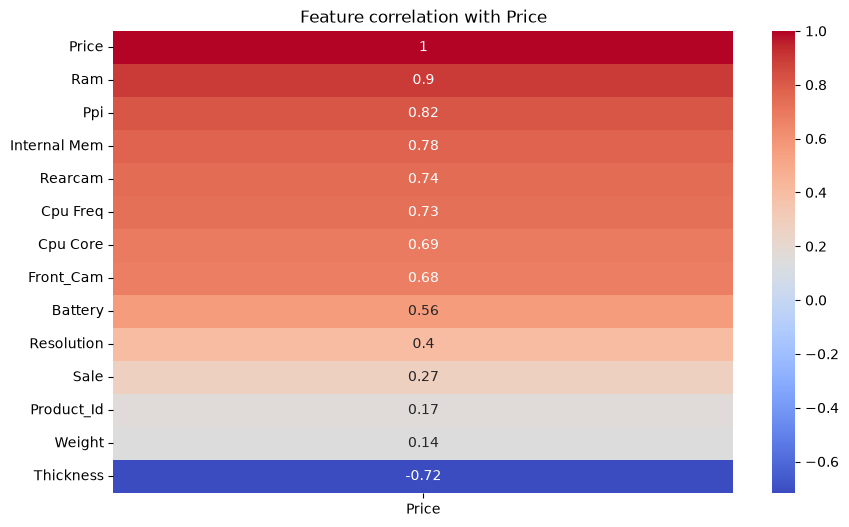

In [100]:
plt.figure(figsize=(10,6))
sns.heatmap(price_corr,annot=True,cmap='coolwarm')
plt.title("Feature correlation with Price")
plt.show()


Identify the top 4 features most correlated with Price

Features:  Ram, Ppi,Internalmem,Rearcam  are most correlated top 4 features with price
Thickness also have nagative correlation with good strength

Plot scatter plots for these features against Price and analyze the relationships

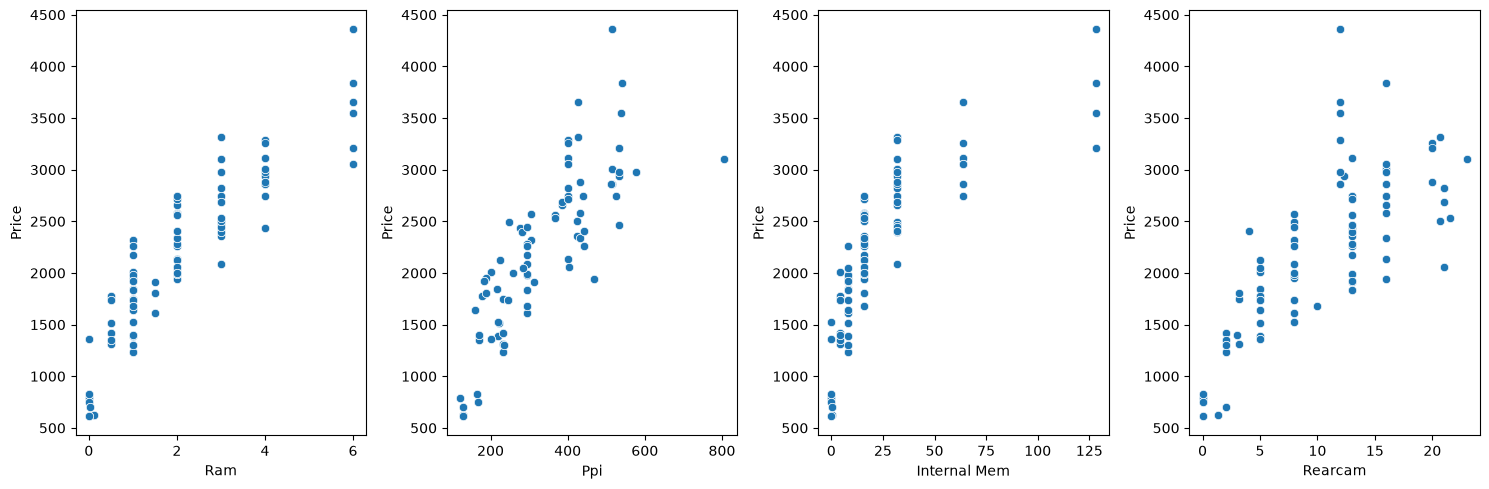

In [101]:
fig,axes=plt.subplots(ncols=4,figsize=(15,5))
features=["Ram","Ppi","Internal Mem","Rearcam"]
for index,col in enumerate(features):
    sns.scatterplot(data=df,x=col,y='Price',ax=axes[index])
plt.tight_layout()
plt.show()
                    
                           

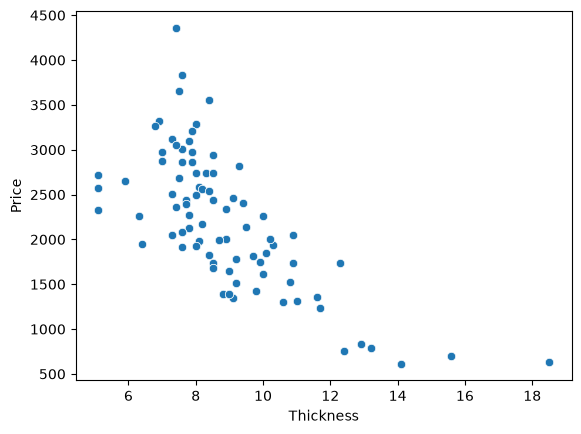

In [102]:
sns.scatterplot(data=df,x="Thickness",y="Price")
plt.show()

2.Prepare the Data:

Feature Selection: Select the features and the target variable for your analysis

In [103]:
df.columns

Index(['Product_Id', 'Price', 'Sale', 'Weight', 'Resolution', 'Ppi',
       'Cpu Core', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Front_Cam',
       'Battery', 'Thickness'],
      dtype='str')

In [104]:
correlation_matrix=df.corr()
inter_feature_corr=correlation_matrix.drop("Price",axis=0).drop("Price",axis=1).drop("Product_Id",axis=0).drop("Product_Id",axis=1)
inter_feature_corr

,Sale,Weight,Resolution,Ppi,Cpu Core,Cpu Freq,Internal Mem,Ram,Rearcam,Front_Cam,Battery,Thickness
Sale,1.000000,0.016114,0.017154,0.235896,0.069517,0.099133,0.489308,0.373127,0.292164,0.437233,0.120338,-0.047991
Weight,0.016114,1.000000,0.890416,-0.054683,0.216257,0.222730,0.098849,0.149283,-0.029448,-0.005971,0.833783,-0.185262
Resolution,0.017154,0.890416,1.000000,0.181292,0.472226,0.505454,0.202660,0.327216,0.249892,0.202720,0.843462,-0.533708
Ppi,0.235896,-0.054683,0.181292,1.000000,0.487990,0.713168,0.618560,0.748724,0.774008,0.491371,0.302517,-0.496791
Cpu Core,0.069517,0.216257,0.472226,0.487990,1.000000,0.491519,0.276251,0.483128,0.611353,0.586698,0.459728,-0.697935
Cpu Freq,0.099133,0.222730,0.505454,0.713168,0.491519,1.000000,0.441400,0.633547,0.625104,0.358319,0.473137,-0.614458
Internal Mem,0.489308,0.098849,0.202660,0.618560,0.276251,0.441400,1.000000,0.875354,0.451917,0.555733,0.461506,-0.367412
Ram,0.373127,0.149283,0.327216,0.748724,0.483128,0.633547,0.875354,1.000000,0.648073,0.647470,0.541001,-0.521074
Rearcam,0.292164,-0.029448,0.249892,0.774008,0.611353,0.625104,0.451917,0.648073,1.000000,0.596374,0.287821,-0.550998
Front_Cam,0.437233,-0.005971,0.202720,0.491371,0.586698,0.358319,0.555733,0.647470,0.596374,1.000000,0.295283,-0.493542


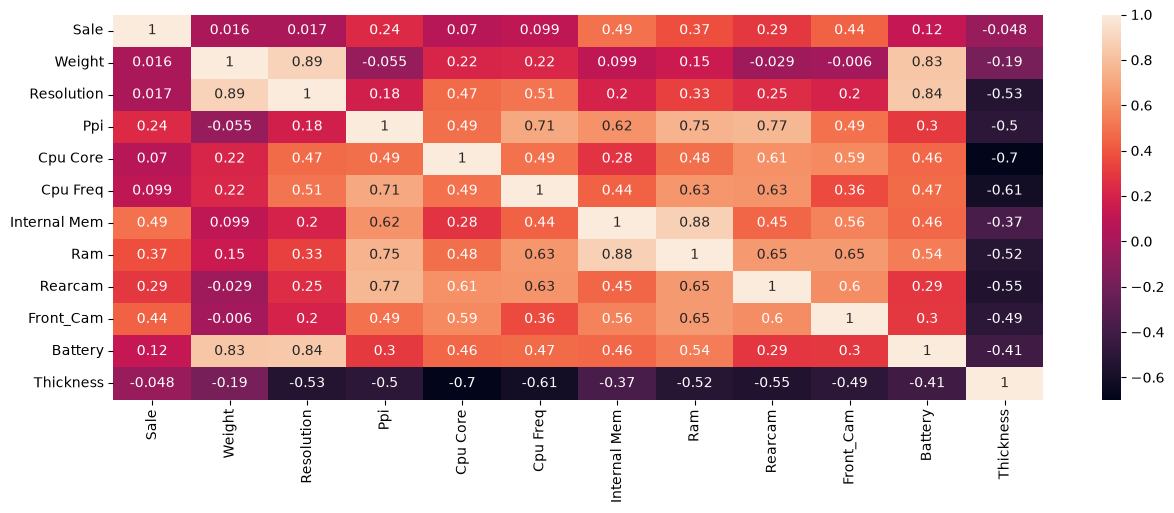

In [105]:
plt.figure(figsize=(15,5))
sns.heatmap(inter_feature_corr,annot=True)
plt.show()

In [106]:
#target_corr=price_corr.drop("Product_Id")

In [107]:
#selected_Features=[]
#for feature in target_corr.index:
    #if feature=="Price":
       #continue
    #if all (inter_feature_corr[feature].loc[selected_Features])<0.75):
        #selected_Features.append(feature)
        #print(f'selected : {feature} high correlation with price')
    #else:
       # print(f'Rejected :{feature} due to high intercorlation ')
    



In [108]:
#selected_Features

feature selection based on select kbest

In [109]:
from sklearn.feature_selection import SelectKBest,f_classif

In [110]:
df.columns

Index(['Product_Id', 'Price', 'Sale', 'Weight', 'Resolution', 'Ppi',
       'Cpu Core', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Front_Cam',
       'Battery', 'Thickness'],
      dtype='str')

In [111]:
x=df[df.columns[2:]]


In [112]:
x

,Sale,Weight,Resolution,Ppi,Cpu Core,Cpu Freq,Internal Mem,Ram,Rearcam,Front_Cam,Battery,Thickness
0,10,135.0,5.20,424,8,1.350,16.0,3.000,13.00,8.0,2610,7.4
1,10,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
2,10,110.0,4.70,312,4,1.200,8.0,1.500,13.00,5.0,2000,7.6
3,11,118.5,4.00,233,2,1.300,4.0,0.512,3.15,0.0,1400,11.0
4,11,125.0,4.00,233,2,1.300,4.0,1.000,3.15,0.0,1700,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...
156,4638,178.0,5.46,538,4,1.875,128.0,6.000,12.00,16.0,4080,8.4
157,8016,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9
158,8809,150.0,5.50,401,8,2.200,64.0,4.000,20.00,20.0,3000,6.8
159,8946,170.0,5.50,534,4,1.975,128.0,6.000,20.00,8.0,3400,7.9


In [113]:
y=df["Price"]

In [114]:
x.shape

(161, 12)

In [115]:
y.shape

(161,)

In [116]:
from sklearn.feature_selection import f_regression

In [117]:
seletor=SelectKBest(score_func=f_regression,k=6)

In [118]:
x_new=seletor.fit_transform(x,y)

In [119]:
x_new.shape

(161, 6)

In [120]:
x.columns

Index(['Sale', 'Weight', 'Resolution', 'Ppi', 'Cpu Core', 'Cpu Freq',
       'Internal Mem', 'Ram', 'Rearcam', 'Front_Cam', 'Battery', 'Thickness'],
      dtype='str')

In [121]:
seletor.scores_

array([ 12.83103676,   3.39340206,  31.01494774, 320.62844618,
       141.97040903, 178.64110869, 241.82844225, 654.11891465,
       191.92816053, 133.28571711,  72.62283175, 168.00144869])

In [122]:
list(zip(x.columns,seletor.scores_))

[('Sale', np.float64(12.831036761724992)),
 ('Weight', np.float64(3.3934020554838473)),
 ('Resolution', np.float64(31.01494773718342)),
 ('Ppi', np.float64(320.6284461796825)),
 ('Cpu Core', np.float64(141.97040902596663)),
 ('Cpu Freq', np.float64(178.64110868764752)),
 ('Internal Mem', np.float64(241.82844225223644)),
 ('Ram', np.float64(654.1189146536362)),
 ('Rearcam', np.float64(191.9281605286103)),
 ('Front_Cam', np.float64(133.28571710548528)),
 ('Battery', np.float64(72.62283175080098)),
 ('Thickness', np.float64(168.0014486909613))]

In [123]:
x.columns[seletor.get_support(indices=True)]

Index(['Ppi', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Thickness'], dtype='str')

In [124]:
selected_df=pd.DataFrame(x_new,columns=x.columns[seletor.get_support(indices=True)])
selected_df

,Ppi,Cpu Freq,Internal Mem,Ram,Rearcam,Thickness
0,424.0,1.350,16.0,3.000,13.00,7.4
1,233.0,1.300,4.0,1.000,3.15,9.9
2,312.0,1.200,8.0,1.500,13.00,7.6
3,233.0,1.300,4.0,0.512,3.15,11.0
4,233.0,1.300,4.0,1.000,3.15,9.9
...,...,...,...,...,...,...
156,538.0,1.875,128.0,6.000,12.00,8.4
157,534.0,1.975,128.0,6.000,20.00,7.9
158,401.0,2.200,64.0,4.000,20.00,6.8
159,534.0,1.975,128.0,6.000,20.00,7.9


Split the Dataset: 
Divide the dataset into training and testing sets. Use 80% of the data for training and 20% for testing.



In [125]:
x=selected_df
y=df["Price"]

In [126]:
x.shape

(161, 6)

In [127]:
y.shape

(161,)

In [128]:
from sklearn.model_selection import train_test_split

In [129]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [130]:
x_train.shape

(128, 6)

In [131]:
x_test.shape

(33, 6)

In [132]:
y_train.shape

(128,)

In [133]:
y_test.shape

(33,)

Build and Train the Model:
Create a Linear Regression Model: Build a linear regression model using the training data.
Train the Model: Fit the model to the training data.


In [134]:
from sklearn.linear_model import LinearRegression

In [135]:
model=LinearRegression()

In [136]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.09,103.65, 3.4 ,180.58, 10.85,-93.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Ppi','Cpu Freq','Internal Mem','Ram','Rearcam','Thickness']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1937
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


Evaluate the Model:

Predict: Use the model to make predictions on the test set.

In [137]:
y_pred=model.predict(x_test)

Metrics Calculation: Evaluate the model’s performance using the following metrics:

Slope (Coefficient) and Intercept: Print the slope (coefficient) and intercept of the regression line.

In [138]:
print(f'slope(coefficient) : {model.coef_}')
print(f'Intercept : {model.intercept_}')

slope(coefficient) : [  1.08618817 103.64880325   3.39789147 180.57553731  10.8477479
 -93.35506346]
Intercept : 1937.2586386978146


Model Performance Metrics: Calculate and report the following metrics:

In [139]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

R² Score: How well does the model explain the variance in the target variable?

In [140]:
print(f'r2_score : {r2_score(y_test,y_pred)}')

r2_score : 0.90715724800149


Mean Absolute Error (MAE): What is the average absolute difference between predicted and actual values?

In [141]:
print(f'MAE : {mean_absolute_error(y_test,y_pred)}')

MAE : 182.49729524537202


Mean Squared Error (MSE): What is the average of the squared differences between predicted and actual values?

In [142]:
print(f'MSE : {mean_squared_error(y_test,y_pred)}')

MSE : 52631.53765110007


Model Evaluation: Based on the performance metrics, assess how well the model predicts mobile prices. Discuss whether the model’s performance is satisfactory or if there are areas for improvement.

In [143]:
df.head()

,Product_Id,Price,Sale,Weight,Resolution,Ppi,Cpu Core,Cpu Freq,Internal Mem,Ram,Rearcam,Front_Cam,Battery,Thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [144]:
to_test=pd.DataFrame({"Ppi":[400],"Cpu Freq":[1.29],"Internal Mem":[15.2],"Ram":[2.9],"Rearcam":[12.5],"Thickness":[7.2]})

In [145]:
to_test

,Ppi,Cpu Freq,Internal Mem,Ram,Rearcam,Thickness
0,400,1.29,15.2,2.9,12.5,7.2


In [146]:
model.predict(to_test)

array([2544.19826485])

Tested model using to_test values which is likely 1st row of df.

autual price : 2357. 

model predicted : 2544 which is close to actual price.

1.What insights did you gain   from the correlation analysis and scatter plots?

correlation analysis :Ram, Ppi,Internalmem,Rearcam,cpu Freq are highly correlated with price.

Thickness also have nagative correlation with good strength.

better hardwares directly linked with higher price.phone gets more thin, price is high

From Scatter plots : Ram, Ppi,Internalmem,Rearcam has positive linear relationship with price. 

and Thickness has negative linear relationship with price

2.How do the selected features contribute to the prediction of mobile prices?

selected features acting like buliding blocks for smartphone. model combines hardware contribution to calculate price

3.What do the slope (coefficient) and intercept reveal about the relationship between the features and the target variable?

In [147]:
model.coef_

array([  1.08618817, 103.64880325,   3.39789147, 180.57553731,
        10.8477479 , -93.35506346])

In [148]:
model.intercept_

np.float64(1937.2586386978146)

In [149]:
selected_df.columns

Index(['Ppi', 'Cpu Freq', 'Internal Mem', 'Ram', 'Rearcam', 'Thickness'], dtype='str')

we can write our predition equation as 

 y=1937.25 +(Ppi * 1.08618817) +(Cpu Freq*103.64880325) +(Internal Mem*3.39789147)+(Ram*180.57553731) +(Rearcam*10.8477479 )+(Thickness*(93.35506346))


features are not contributing equally. their impact is determined by their slopes. example if there is one unit increse in ppi price get incresed by 1.08618817.

4.How well does the model perform based on the evaluation metrics? Are there any discrepancies between the predicted and actual values?

In [150]:
r2_score(y_test,y_pred)

0.90715724800149

model r2 score is0.90715. that is 90.77% model explains variance in price  

MAE : 182.49729524537202 
RMSE :229

since rmse is higher , it may be accurate for average phones. it may make fewer errors for higher budget phone

In [151]:
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
rmse

np.float64(229.41564386741388)

5.What might be some potential improvements or additional steps you could take to enhance the model’s performance?

columns might needs to be sclaed. all are in different scales. ridge/lasso regularization needs to be applied to avoid overfitting

outliers are not handled. once outliers are handled model performace might be improved.


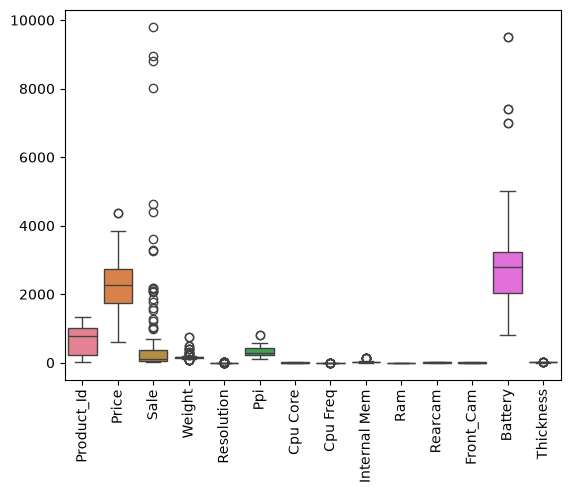

In [152]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()
